In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import selfies as sf
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
import math
from rdkit import Chem
from rdkit.Chem import Draw, AllChem, DataStructs, rdmolops, Descriptors, rdMolDescriptors, QED
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
#import plotly.express as px
from IPython.display import display
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline
import re
import difflib
from datasets import load_dataset

import sys
import sascorer

torch.cuda.empty_cache()

In [16]:
# Load ZINC250K dataset
ds = load_dataset("edmanft/zinc250k")["train"]
df = ds.to_pandas()

print(df.head())

   index                                             smiles  \
0      0          CC(C)(C)c1ccc2occ(CC(=O)Nc3ccccc3F)c2c1\n   
1      1     C[C@@H]1CC(Nc2cncc(-c3nncn3C)c2)C[C@@H](C)C1\n   
2      2  N#Cc1ccc(-c2ccc(O[C@@H](C(=O)N3CCCC3)c3ccccc3)...   
3      3  CCOC(=O)[C@@H]1CCCN(C(=O)c2nc(-c3ccc(C)cc3)n3c...   
4      4  N#CC1=C(SCC(=O)Nc2cccc(Cl)c2)N=C([O-])[C@H](C#...   

                                             selfies     logP       qed  \
0  [C][C][Branch1][C][C][Branch1][C][C][C][=C][C]...  5.05060  0.702012   
1  [C][C@@H1][C][C][Branch2][Ring1][Ring2][N][C][...  3.11370  0.928975   
2  [N][#C][C][=C][C][=C][Branch2][Ring2][Ring2][C...  4.96778  0.599682   
3  [C][C][O][C][=Branch1][C][=O][C@@H1][C][C][C][...  4.00022  0.690944   
4  [N][#C][C][=C][Branch2][Ring1][Ring1][S][C][C]...  3.60956  0.789027   

        SAS  
0  2.084095  
1  3.432004  
2  2.470633  
3  2.822753  
4  4.035182  


In [ ]:
# load tokenizer
import json

#TOKENIZER_PATH = ""

# df = pd.read_csv(ZINC_PATH)

with open(TOKENIZER_PATH) as f:
    tokenizer = json.load(f)

tok2id = tokenizer["tok2id"]
id2tok = tokenizer["id2tok"]
id2tok = {int(k): v for k, v in id2tok.items()}
special = tokenizer["special_tokens"]

PAD = special["PAD"]
SOS = special["SOS"]
EOS = special["EOS"]
max_len = tokenizer["max_len"]
vocab_size = tokenizer["vocab_size"]

df = df[df["selfies"].apply(
    lambda s: all(t in tok2id for t in sf.split_selfies(s))
)]


def encode(s):
    return np.array(
        [tok2id[SOS]] +
        [tok2id[t] for t in sf.split_selfies(s)] +
        [tok2id[EOS]],
        dtype=np.int64
    )


seqs = df["selfies"].apply(encode)

seqs = [s for s in seqs if len(s) <= max_len]

data = np.full(
    (len(seqs), max_len),
    tok2id[PAD],
    dtype=np.int64
)

for i, s in enumerate(seqs):
    data[i, :len(s)] = s


train, tmp = train_test_split(data, test_size=0.2, random_state=42)
val, test = train_test_split(tmp, test_size=0.5, random_state=42)

print(train.shape, val.shape, test.shape)

# np.savez(
#     train=train,
#     val=val,
#     test=test
# )

(195247, 77) (24406, 77) (24406, 77)


In [8]:
class PositionalEmbedding(nn.Module):
    def __init__(self, max_len, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        pe = torch.zeros(max_len, hidden_size)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, hidden_size, 2).float() * (-math.log(10000.0) / hidden_size))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe)

    def forward(self, x):
        if x.dim() == 3:
            B, T, _ = x.shape
        elif x.dim() == 2:
            B, T = x.shape
        if T <= self.pe.size(0):
            pe = self.pe[:T]
        else:
            device = x.device
            H = self.hidden_size
            position = torch.arange(T, dtype=torch.float, device=device).unsqueeze(1)
            div_term = torch.exp(torch.arange(0, H, 2, device=device).float() * (-math.log(10000.0) / H))
            pe = torch.zeros(T, H, device=device)
            pe[:, 0::2] = torch.sin(position * div_term)
            pe[:, 1::2] = torch.cos(position * div_term)
        return pe.unsqueeze(0)


class MultiHeadAttention(nn.Module):
    def __init__(self, hidden_size, num_heads):
        super().__init__()
        self.d = hidden_size // num_heads
        self.num_heads = num_heads
        self.W_q = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W_k = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W_v = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W_o = nn.Linear(hidden_size, hidden_size, bias=False)
        self.norm1 = nn.LayerNorm(hidden_size)
        self.ff = nn.Sequential(
            nn.Linear(hidden_size, 2 * hidden_size),
            nn.GELU(),
            nn.Dropout(p=0.1),
            nn.Linear(2 * hidden_size, hidden_size),
            nn.Dropout(p=0.1),
        )
        self.norm2 = nn.LayerNorm(hidden_size)

    def forward(self, q, k, v, pad_mask=None, causal=False):
        B, T_q, H = q.shape
        _, T_v, _ = v.shape
        Q = self.W_q(q)
        K = self.W_k(k)
        Vx = self.W_v(v)
        Q = Q.view(B, self.num_heads, T_q, self.d)
        K = K.view(B, self.num_heads, T_v, self.d)
        V = Vx.view(B, self.num_heads, T_v, self.d)

        attn_logits = torch.einsum("baih,bajh->baij", Q, K)

        if pad_mask is not None:
            key_mask = pad_mask[:, None, None, :]
            attn_logits = attn_logits.masked_fill(~key_mask, float("-inf"))

        attn = F.softmax(attn_logits / math.sqrt(self.d), dim=-1)

        if pad_mask is not None:
            query_mask = pad_mask[:, None, :, None]
            attn = attn * query_mask.float()

        h = torch.einsum("baij,bajh->baih", attn, V)
        h = h.view(B, T_q, H)
        h = q + self.W_o(h)
        h = h + self.ff(self.norm2(h))
        h = self.norm1(h)
        return h


class MultiSlotPooling(nn.Module):
    def __init__(self, hidden_size, num_slots):
        super().__init__()
        self.queries = nn.Parameter(torch.empty(num_slots, hidden_size))
        nn.init.uniform_(self.queries, a=-1.0, b=1.0)
        self.W_k = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W_v = nn.Linear(hidden_size, hidden_size, bias=False)

    def forward(self, h, mask):
        k = self.W_k(h)
        v = self.W_v(h)
        attn = torch.einsum("kd,btd->bkt", self.queries, k)
        attn = attn.masked_fill(~mask[:, None, :], -1e9)
        attn = F.softmax(attn, dim=-1) / math.sqrt(h.size(-1))
        slots = torch.einsum("bkt,btd->bkd", attn, v)
        return slots


class VaeTransformer(nn.Module):
    def __init__(self, vocab_size, hidden_size, latent_size, max_len, attn_heads=8, num_slots=8, encoder_layers=1, decoder_layers=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_slots = num_slots
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.pos_encoder = PositionalEmbedding(max_len, hidden_size)
        self.conv_pos = nn.Conv1d(hidden_size, hidden_size, kernel_size=3, padding=1, groups=hidden_size)

        self.pos_block = MultiHeadAttention(hidden_size, attn_heads)
        self.encoder_blocks = nn.ModuleList([MultiHeadAttention(hidden_size, attn_heads) for _ in range(encoder_layers)])
        self.pool = MultiSlotPooling(hidden_size, num_slots=num_slots)
        self.slots_mix = MultiHeadAttention(hidden_size, num_heads=num_slots)

        self.slot_gamma = nn.Parameter(torch.ones(1, num_slots, hidden_size))
        self.slot_beta = nn.Parameter(torch.zeros(1, num_slots, hidden_size))

        self.slot_mu = nn.Linear(hidden_size, latent_size)
        self.slot_logvar = nn.Linear(hidden_size, latent_size)

        self.slot_compress_mu = nn.Linear(hidden_size, latent_size // num_slots)
        self.slot_compress_logvar = nn.Linear(hidden_size, latent_size // num_slots)

        self.fc_mu = nn.Linear(num_slots * hidden_size, latent_size)
        self.fc_logvar = nn.Linear(num_slots * hidden_size, latent_size)

        self.latent_query = nn.Parameter(torch.randn(1, 1, latent_size))
        self.latent_key = nn.Linear(latent_size, latent_size)

        self.max_len = max_len
        self.z_to_slot = nn.Linear(hidden_size // num_slots, hidden_size)
        self.decoder_embed = nn.Embedding(vocab_size, hidden_size)
        self.decoder_pos = PositionalEmbedding(max_len, hidden_size)

        self.z_to_memory = nn.Linear(latent_size, hidden_size)
        self.slots_to_memory = nn.Linear(latent_size // num_slots, hidden_size)

        self.decoder_layer = nn.TransformerDecoderLayer(
            d_model=hidden_size,
            nhead=attn_heads,
            dim_feedforward=2 * hidden_size,
            batch_first=True,
        )

        self.decoder_transformer = nn.TransformerDecoder(
            self.decoder_layer,
            num_layers=decoder_layers,
        )
        self.fc_output = nn.Linear(hidden_size, vocab_size)
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def causal_mask(self, T, device):
        return torch.triu(torch.ones(T, T, device=device), diagonal=1).bool()

    def encode(self, x, mode=None):
        B, _ = x.shape
        h = self.embedding(x)
        fourier_pos_encoding = self.pos_encoder(x)
        conv_pos_encoding = self.conv_pos(h.transpose(1, 2)).transpose(1, 2)
        h = h + fourier_pos_encoding + conv_pos_encoding
        mask = x != 0

        for block in self.encoder_blocks:
            h = block(h, h, h, pad_mask=mask)

        h = h.masked_fill(~mask[:, :, None], 0.0)
        slots = self.pool(h, mask)
        slots = F.layer_norm(slots, slots.shape[-1:])

        B, K, Z = slots.shape

        slots_mu = self.slot_mu(slots)
        slots_logvar = self.slot_logvar(slots)

        q = F.normalize(self.latent_query.expand(B, 1, Z), dim=-1)
        k = F.normalize(self.latent_key(slots_mu), dim=-1)

        logits = torch.einsum("bqz,bkz->bqk", q, k)

        confidence = -torch.logsumexp(slots_logvar, dim=-1).unsqueeze(1)
        confidence_scale = 0.5

        logits = logits + confidence_scale * confidence
        attn = torch.softmax(logits / 0.5, dim=-1)

        mu = torch.einsum("bqk,bkz->bqz", attn, slots_mu).squeeze(1)

        var = torch.exp(slots_logvar)
        var_agg = torch.einsum("bqk,bkz->bqz", attn, var).squeeze(1)
        logvar = torch.log(var_agg + 1e-8)

        if mode == "test":
            return mu, logvar, slots
        else:
            return mu, logvar

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        else:
            return mu

    def decode(self, z, x_in=None, max_len=80, start_id=1, eos_id=2):
        B = z.size(0)
        device = z.device

        memory = self.z_to_memory(z).unsqueeze(1)

        if x_in is not None:
            x_emb = self.decoder_embed(x_in)
            x_emb = x_emb + self.decoder_pos(x_emb)

            T = x_emb.size(1)
            tgt_mask = self.causal_mask(T, device)

            h = self.decoder_transformer(
                tgt=x_emb,
                memory=memory,
                tgt_mask=tgt_mask,
            )

            logits = self.fc_output(h)
            return logits

        else:
            tokens = torch.full((B, 1), start_id, dtype=torch.long, device=device)
            finished = torch.zeros(B, dtype=torch.bool, device=device)
            max_len = self.max_len * 2

            for _ in range(max_len):
                x_emb = self.decoder_embed(tokens)
                x_emb = x_emb + self.decoder_pos(x_emb)

                T = tokens.size(1)
                tgt_mask = self.causal_mask(T, device)

                h = self.decoder_transformer(
                    tgt=x_emb,
                    memory=memory,
                    tgt_mask=tgt_mask,
                )

                logits_step = self.fc_output(h[:, -1])
                next_token = torch.argmax(logits_step, dim=-1, keepdim=True)

                next_token = torch.where(
                    finished.unsqueeze(1),
                    torch.full_like(next_token, eos_id),
                    next_token,
                )

                tokens = torch.cat([tokens, next_token], dim=1)
                finished |= next_token.squeeze(1) == eos_id

                if finished.all():
                    break

            return tokens

    def forward(self, x, mode="eval"):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)

        if mode == "train":
            x_in = x[:, :-1]
            logits = self.decode(z, x_in=x_in)
            return logits, mu, logvar

        if mode == "eval":
            tokens = self.decode(z, x_in=None)
            return tokens, mu, logvar

        if mode == "test":
            mu, logvar, slots = self.encode(x, mode="test")
            z = self.reparameterize(mu, logvar)
            tokens = self.decode(z, x_in=None)
            return tokens, mu, logvar, slots


def vae_loss(logits, targets, mu, logvar, beta=0.01, pad_id=0):
    B, T, V = logits.shape

    logits = logits.reshape(-1, V)
    targets = targets.reshape(-1)

    rec_loss = F.cross_entropy(
        logits,
        targets,
        ignore_index=pad_id,
    )

    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    return rec_loss + beta * kl, rec_loss, kl


In [ ]:
# loading saved model
device = 'cuda' if torch.cuda.is_available() else 'cpu'

hidden_size = 256
attention_heads = 8
encoder_layers = 3
decoder_layers = 2
latent_size = 256

model = VaeTransformer(
    vocab_size,
    hidden_size,
    latent_size,
    max_len,
    attention_heads,
    encoder_layers=encoder_layers,
    decoder_layers=decoder_layers
).to(device)

ckpt_path = "/checkpoints/H256-L256-3E-2D-Final-NoCorruption.pt"

ckpt = torch.load(
    ckpt_path,
    map_location=device,
    weights_only=False
)

# checkpoint contains {'model': state_dict, ...}
state_dict = ckpt["model"]

model.load_state_dict(state_dict)

model.eval()

print("Model loaded")

Model loaded


In [ ]:
# load properties and confounds dataframe
Y = pd.read_csv('/data/molecule_properties_ZINC250K.csv')
X = pd.read_csv('/data/confound_features_ZINC250K.csv')    

In [13]:
def get_molecule_properties(mol):
    return {
        "molWt": Descriptors.MolWt(mol),
        "HeavyAtomCount": mol.GetNumHeavyAtoms(),
        "cLogP": Descriptors.MolLogP(mol),
        "TPSA": Descriptors.TPSA(mol),
        "HBD": rdMolDescriptors.CalcNumHBD(mol),
        "HBA": rdMolDescriptors.CalcNumHBA(mol),
        "NumRotatableBonds": rdMolDescriptors.CalcNumRotatableBonds(mol),
        "RingCount": rdMolDescriptors.CalcNumRings(mol),
        "AromaticRingCount": rdMolDescriptors.CalcNumAromaticRings(mol),
        "FractionCSP3": rdMolDescriptors.CalcFractionCSP3(mol),
        "NumSpiroAtoms": rdMolDescriptors.CalcNumSpiroAtoms(mol),
        "NumBridgeheadAtoms": rdMolDescriptors.CalcNumBridgeheadAtoms(mol),
        "BertzCT": Descriptors.BertzCT(mol),
        "QED": QED.qed(mol),
        "SA-score": sascorer.calculateScore(mol)
    }

def compute_property(mol, name):
    if name == "molWt":
        return Descriptors.MolWt(mol)
    elif name == "HeavyAtomCount":
        return mol.GetNumHeavyAtoms()
    elif name == "cLogP":
        return Descriptors.MolLogP(mol)
    elif name == "TPSA":
        return Descriptors.TPSA(mol)
    elif name == "HBD":
        return rdMolDescriptors.CalcNumHBD(mol)
    elif name == "HBA":
        return rdMolDescriptors.CalcNumHBA(mol)
    elif name == "NumRotatableBonds":
        return rdMolDescriptors.CalcNumRotatableBonds(mol)
    elif name == "RingCount":
        return rdMolDescriptors.CalcNumRings(mol)
    elif name == "AromaticRingCount":
        return rdMolDescriptors.CalcNumAromaticRings(mol)
    elif name == "FractionCSP3":
        return rdMolDescriptors.CalcFractionCSP3(mol)
    elif name == "NumSpiroAtoms":
        return rdMolDescriptors.CalcNumSpiroAtoms(mol)
    elif name == "NumBridgeheadAtoms":
        return rdMolDescriptors.CalcNumBridgeheadAtoms(mol)
    elif name == "BertzCT":
        return Descriptors.BertzCT(mol)
    elif name == "QED":
        return QED.qed(mol)
    elif name == "SA-score":
        return sascorer.calculateScore(mol)
    else:
        return np.nan

def clean_selfie_ids(ids):
    result = []
    for tok in ids:
        if tok == 1:
            continue
        if tok == 2 or tok == 0:
            return result
        result.append(tok)
    return result

def latents_to_mol(model, z):
    ids = model.decode(z)
    tokens = [[id2tok[id] for id in clean_selfie_ids(seq)] for seq in ids.cpu().numpy()]
    selfies = [''.join(toks) for toks in tokens]
    mols = []
    for selfie in selfies:
        try:
            smi = sf.decoder(selfie)
            mol = Chem.MolFromSmiles(smi)
            mols.append(mol)  
        except:
            mols.append(None)
            print(smi)
    return mols

In [14]:
# extract latents for linear probe
def extract_latents(data, model):
    loader = DataLoader(data, batch_size=128, shuffle=False)
    zs = []
    model.eval()
    with torch.no_grad():
        for x in tqdm(loader):
            x = x.to(device)
            mu, _ = model.encode(x)
            zs.append(mu.cpu().numpy())
    z = np.concatenate(zs, axis=0)
    return z

z = extract_latents(data, model)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1907/1907 [00:05<00:00, 369.46it/s]


In [17]:
valid_mask = df["selfies"].apply(
    lambda s: all(t in tok2id for t in sf.split_selfies(s))
)

valid_mask = valid_mask.values

X = X.loc[valid_mask].reset_index(drop=True)
Y = Y.loc[valid_mask].reset_index(drop=True)

print(X.shape)
print(Y.shape)
print(z.shape)

(244059, 4)
(244059, 15)
(244059, 256)


In [18]:
# first train Ridge Confound -> Y, then latent -> Y - Y(C) where Y is molecule property
for target_name in Y.columns:
    print(f"\n=== Predicting {target_name} ===")
    y = Y[target_name].values
    xc_train, xc_test, z_train, z_test, y_train, y_test = train_test_split(X, z, y, test_size=0.2, random_state=42)

    confound_model = Pipeline([
        ("scaler", StandardScaler()),
        ("linear", LinearRegression())
    ])  

    confound_model.fit(xc_train, y_train)

    y_train_conf = confound_model.predict(xc_train)
    y_test_conf = confound_model.predict(xc_test)
    print("confound R2:", r2_score(y_test, y_test_conf))

    res_train = y_train - y_train_conf
    res_test = y_test - y_test_conf

    linear_probe = Pipeline([
        ("scaler", StandardScaler()),
        ("linear", LinearRegression())
    ])
    linear_probe.fit(z_train, res_train)
    res_pred = linear_probe.predict(z_test)
    print("residual R2:", r2_score(res_test, res_pred)) 


=== Predicting molWt ===
confound R2: 0.8701888243914695
residual R2: 0.5816857037415348

=== Predicting HeavyAtomCount ===
confound R2: 0.9388030734152515
residual R2: 0.7259719134369845

=== Predicting cLogP ===
confound R2: 0.1577049175963703
residual R2: 0.6019576127424886

=== Predicting TPSA ===
confound R2: 0.32773878527469946
residual R2: 0.6326457960344007

=== Predicting HBD ===
confound R2: 0.013238562557708944
residual R2: 0.4216474637988262

=== Predicting HBA ===
confound R2: 0.3344228807087486
residual R2: 0.6578731999883703

=== Predicting NumRotatableBonds ===
confound R2: 0.15663054886281236
residual R2: 0.4045928525748962

=== Predicting RingCount ===
confound R2: 0.6367592254700432
residual R2: 0.8336684521906235

=== Predicting AromaticRingCount ===
confound R2: 0.38894843139459057
residual R2: 0.806333657257418

=== Predicting FractionCSP3 ===
confound R2: 0.2659686575771736
residual R2: 0.8875482709235671

=== Predicting NumSpiroAtoms ===
confound R2: 0.01417926

In [24]:
def clean_selfie_ids(ids):
    clean = []

    for i in ids:
        tok = id2tok[int(i)]

        if tok in ["<PAD>", "<SOS>", "<EOS>", "MASK"]:
            continue

        clean.append(int(i))

    return clean

  0%|                                                                                                                                                                  | 0/12 [00:00<?, ?it/s]

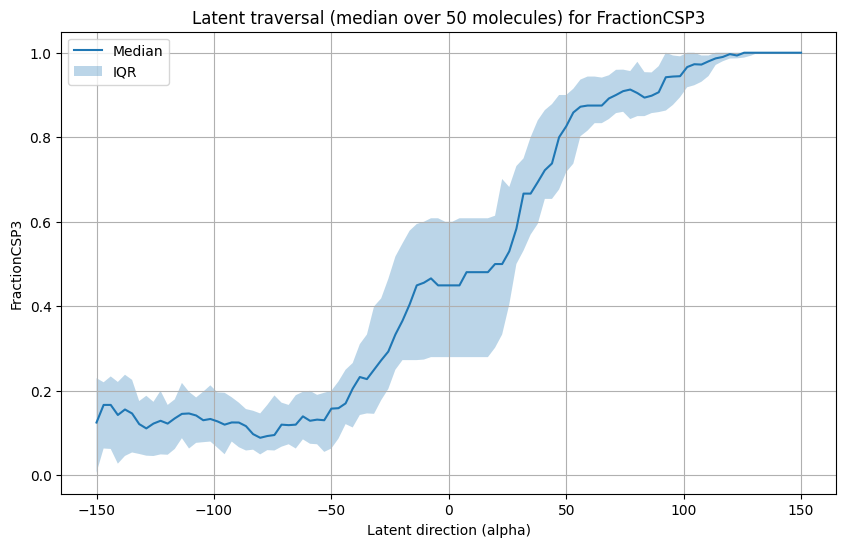

  8%|████████████▊                                                                                                                                             | 1/12 [00:20<03:40, 20.03s/it]

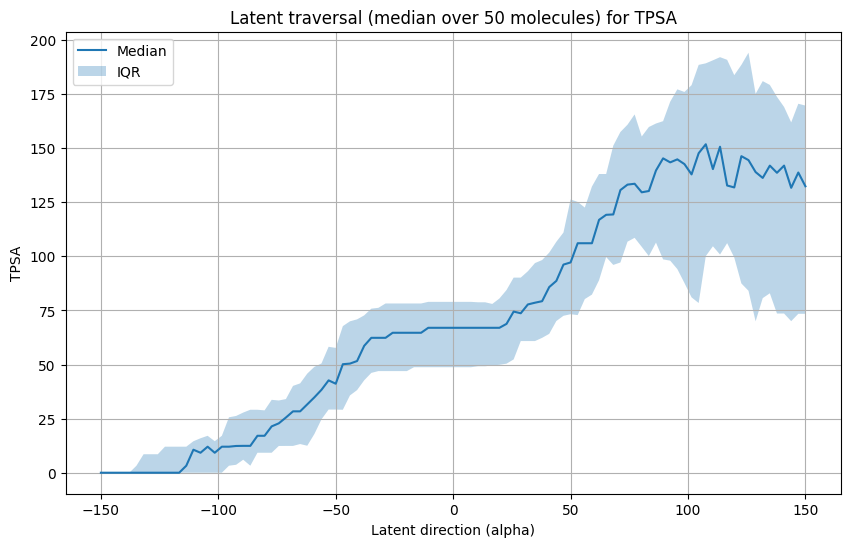

 17%|█████████████████████████▋                                                                                                                                | 2/12 [00:33<02:40, 16.03s/it]

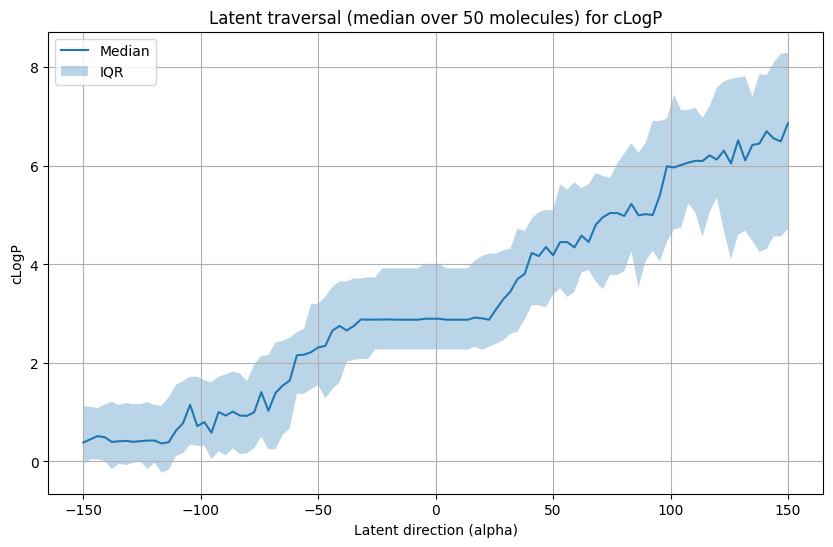

 25%|██████████████████████████████████████▌                                                                                                                   | 3/12 [00:45<02:09, 14.33s/it]

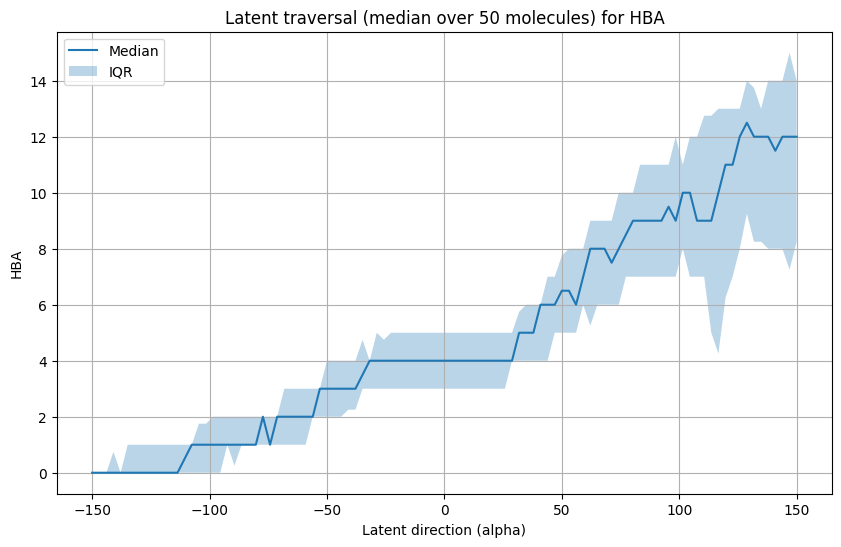

 33%|███████████████████████████████████████████████████▎                                                                                                      | 4/12 [00:57<01:48, 13.56s/it]

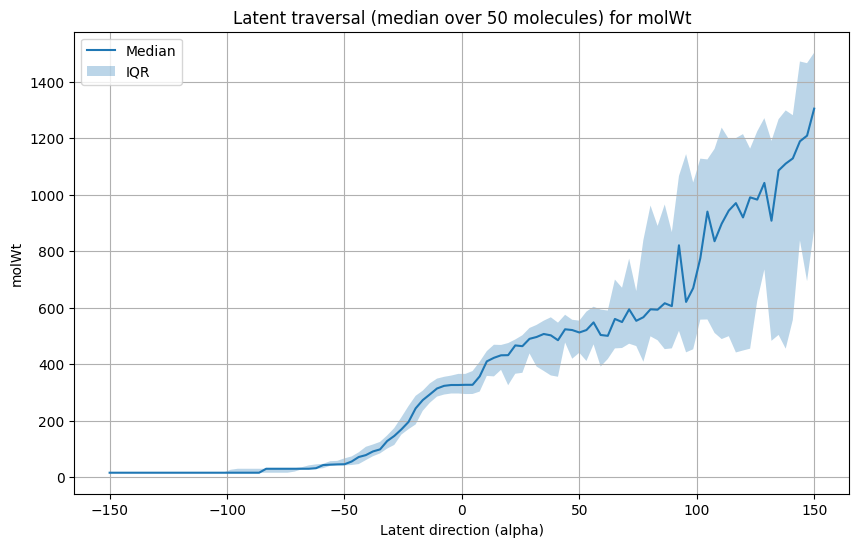

 42%|████████████████████████████████████████████████████████████████▏                                                                                         | 5/12 [01:12<01:36, 13.83s/it]

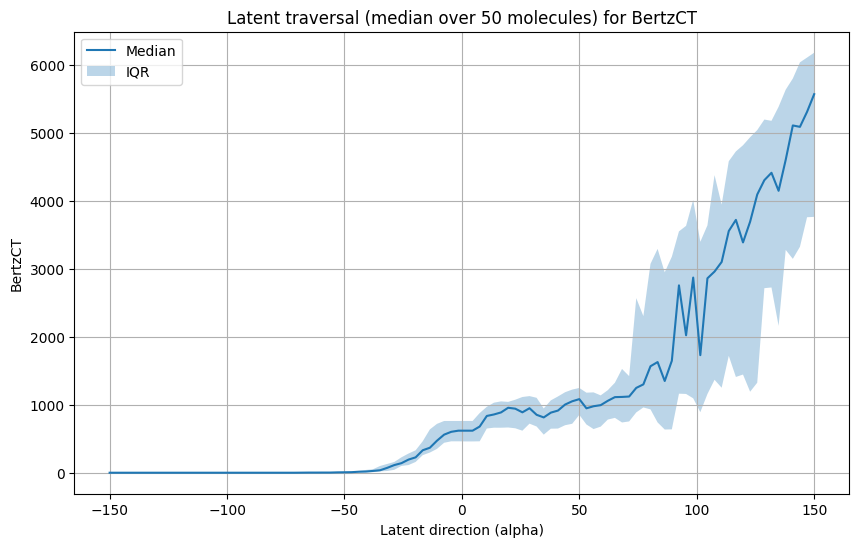

 50%|█████████████████████████████████████████████████████████████████████████████                                                                             | 6/12 [01:32<01:35, 15.93s/it]

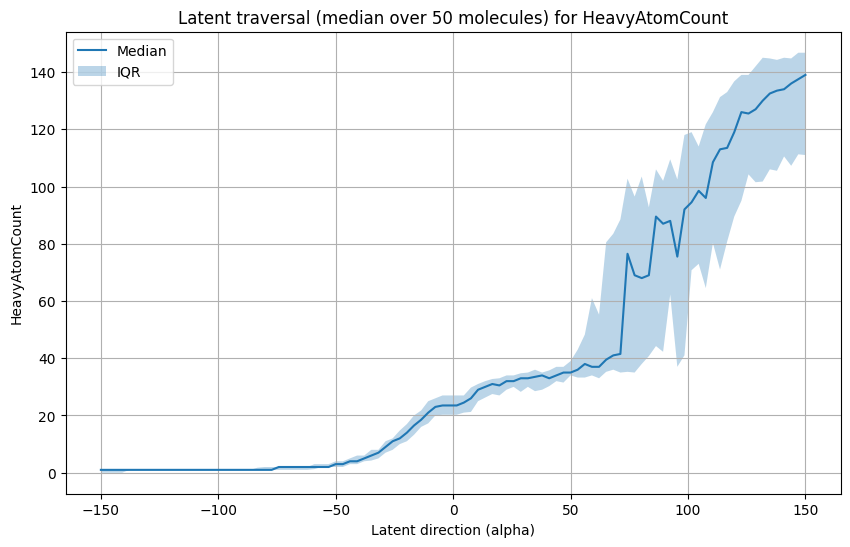

 58%|█████████████████████████████████████████████████████████████████████████████████████████▊                                                                | 7/12 [01:47<01:17, 15.60s/it]

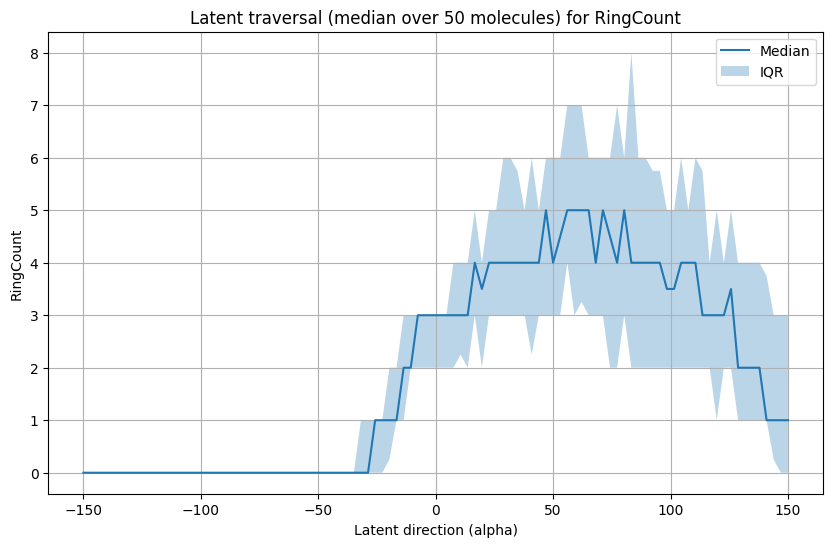

 67%|██████████████████████████████████████████████████████████████████████████████████████████████████████▋                                                   | 8/12 [02:07<01:08, 17.21s/it]

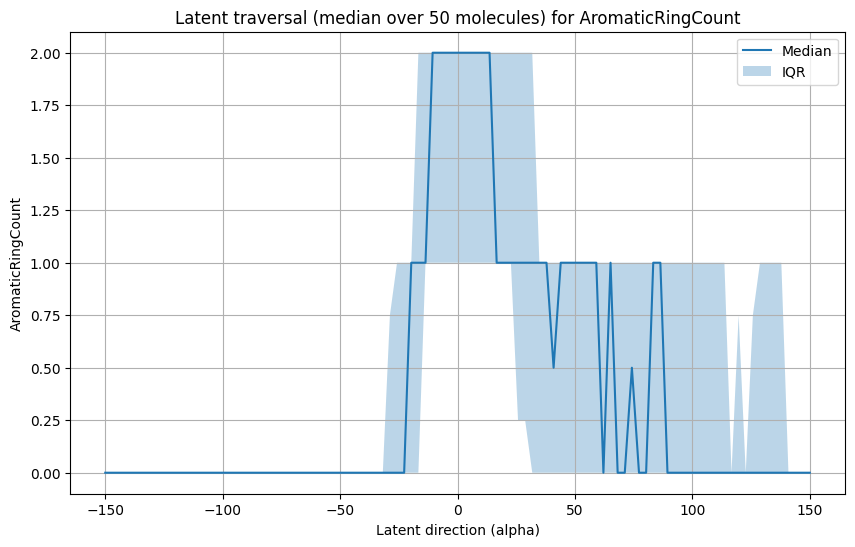

 75%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                                      | 9/12 [02:27<00:53, 17.84s/it]

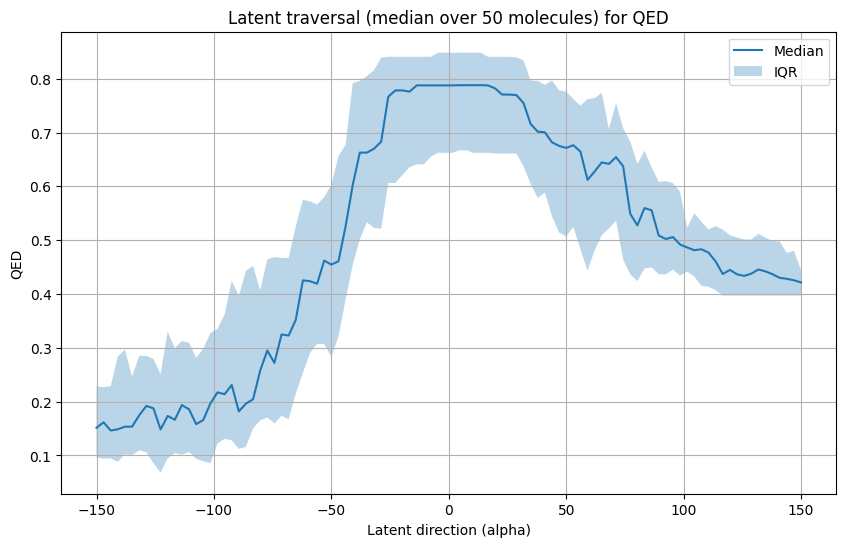

 83%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                         | 10/12 [02:41<00:33, 16.93s/it]

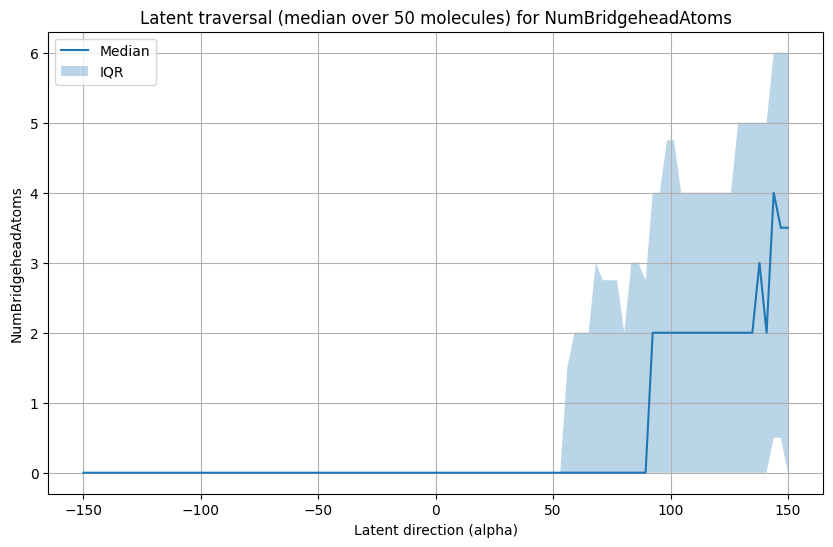

 92%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎            | 11/12 [02:53<00:15, 15.15s/it]

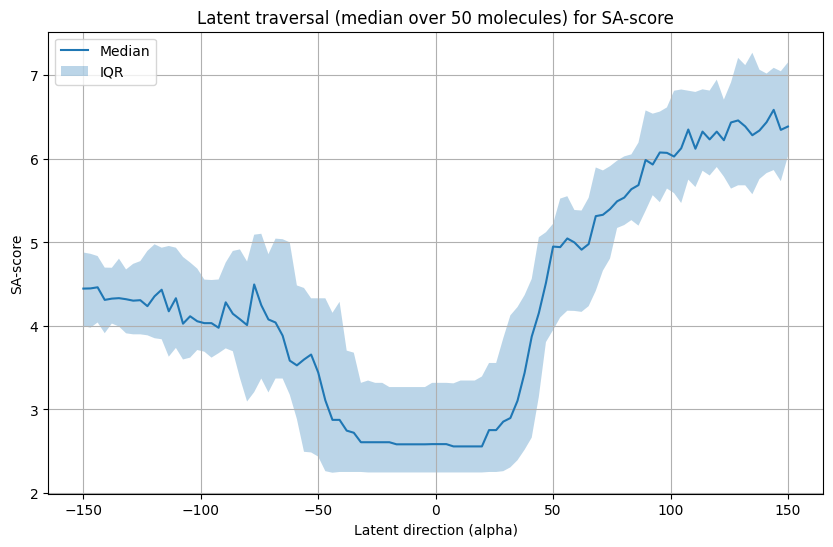

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [03:05<00:00, 15.43s/it]


In [25]:
# gobal latent traversal plot
target_names = ["FractionCSP3", "TPSA", "cLogP", "HBA", "molWt","BertzCT", "HeavyAtomCount", "RingCount", "AromaticRingCount", "QED", "NumBridgeheadAtoms","SA-score"] # Plot for these properties

steps = 100
scale = 150.0
k = 50

for target_name in tqdm(target_names):
    # latent interpolation in rigde direction for poperty
    y = Y[target_name].values
    z_train, z_test, y_train, y_test = train_test_split(z, y, test_size=0.2, random_state=42)

    linear_model = Pipeline([
        ("scaler", StandardScaler()),
        ("linear", LinearRegression())
    ])
    linear_model.fit(z_train, y_train)

    weights_raw = linear_model.named_steps["linear"].coef_
    std = linear_model.named_steps["scaler"].scale_
    weights = weights_raw / std
    weights /= np.linalg.norm(weights)

    #idx = np.random.randint(len(y))
    # sampling from mid molecule in terms of property value
    # idx = Y[target_name].sort_values().index[len(Y) // 2]
    # z0 = z[idx]
    #z0 = np.zeros(latent_size)#np.random.randn(latent_size)  # random point in latent space

    # sorted_idx = Y[target_name].sort_values().index
    # mid = len(sorted_idx) // 2

    # # take a window around median
    # half_k = k // 2
    # selected_idx = sorted_idx[mid - half_k : mid + half_k]

    idx = np.random.randint(0, len(Y), size=k)

    z0_batch = z[idx]   # shape: (k, latent_dim)
    
    def interpolate_batch(z0_batch, direction, steps=1000, scale=100.0):
        alphas = np.linspace(-scale, scale, steps)  # (steps,)
        
        # reshape for broadcasting
        z0_batch = z0_batch[:, None, :]      # (k, 1, d)
        direction = direction[None, None, :] # (1, 1, d)
        alphas = alphas[None, :, None]       # (1, steps, 1)
        
        zs = z0_batch + alphas * direction   # (k, steps, d)
        
        return zs, alphas.squeeze()

    zs, alphas = interpolate_batch(z0_batch, weights, steps, scale)

    k, steps, d = zs.shape
    zs_flat = zs.reshape(-1, d) 

    batch_size = 2048

    props = np.full((k, steps), np.nan)

    model.eval()

    for step_idx, alpha in enumerate(alphas):
        zs_step = z0_batch + alpha * weights   # (k, d)

        row_props = []

        with torch.no_grad():
            for i in range(0, k, batch_size):
                batch = zs_step[i:i+batch_size]
                zs_tensor = torch.tensor(batch, dtype=torch.float32).to(device)

                tokens = model.decode(zs_tensor)
                tokens_list = tokens.detach().cpu().tolist()

                for toks in tokens_list:
                    toks = clean_selfie_ids(toks)
                    selfies = ''.join([id2tok[int(id)] for id in toks])
                    smiles = sf.decoder(selfies)
                    # tokens = [id2tok[int(i)] for i in toks]

                    # print(tokens)
                    # print("".join(tokens))

                    # selfies = "".join(tokens)

                    # smiles = sf.decoder(selfies)

                    mol = Chem.MolFromSmiles(smiles)
                    if mol:
                        val = compute_property(mol, target_name)
                    else:
                        val = np.nan

                    row_props.append(val)

        props[:, step_idx] = row_props

    median_props = np.nanmedian(props, axis=0)  # (steps,)

    alphas = np.array(alphas)
    q25 = np.nanpercentile(props, 25, axis=0)
    q75 = np.nanpercentile(props, 75, axis=0)
    
    plt.figure(figsize=(10, 6))

    plt.plot(alphas, median_props, label="Median")
    plt.fill_between(alphas, q25, q75, alpha=0.3, label="IQR")

    plt.xlabel("Latent direction (alpha)")
    plt.ylabel(target_name)
    plt.title(f"Latent traversal (median over {k} molecules) for {target_name}")
    plt.legend()
    plt.grid()

    plt.show()
    plt.close()